In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf
import shap
import matplotlib.pyplot as plt
import h5py

seed=269

# 1. Data processing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
f = h5py.File('/content/drive/MyDrive/Table_TNG300_snapshot99_SubhalosProp_HaloProp.hdf5', 'r')
f.keys()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<KeysViewHDF5 ['GroupPos_halo', 'M200_halo', 'Spin_halo', 'SubGroupSFR', 'SubGroupStellarPhotom_g', 'SubGroupStellarPhotom_i', 'SubGroupStellarPhotom_r', 'SubGroupStellarPhotom_z', 'SubhaloCM', 'SubhaloGrNr', 'SubhaloId', 'SubhaloMassType', 'SubhaloPos', 'b1', 'b2', 'c200_halo', 'd3_halo', 'd5_halo', 'd8_halo', 'd_minima', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel', 'zform_halo']>

In [3]:
GrNr = np.asarray(f['SubhaloGrNr'])
mass = np.asarray(f['SubhaloMassType'][:,4])
halo_mass = np.asarray(f['M200_halo'])
d3 = np.asarray(f['d3_halo'])
d5 = np.asarray(f['d5_halo'])
d8 = np.asarray(f['d8_halo'])
c_200= np.asarray(f['c200_halo'])
z = np.asarray(f['zform_halo'])
d_min = np.asarray(f['d_minima'])
d_node = np.asarray(f['d_node'])
d_saddle_1 = np.asarray(f['d_saddle_1'])
d_saddle_2 = np.asarray(f['d_saddle_2'])
d_skel = np.asarray(f['d_skel'])
b1 = np.asarray(f['b1'])
spin = np.asarray(f['Spin_halo'])

In [4]:
indices_cambio = np.unique(GrNr, return_index=True)[1]
mass_filtrada = mass[indices_cambio]
halo_mass_filtrada = halo_mass[indices_cambio]
d3 = d3[indices_cambio]
d5 = d5[indices_cambio]
d8 = d8[indices_cambio]
c_200= c_200[indices_cambio]
z = z[indices_cambio]
d_min = d_min[indices_cambio]
d_node = d_node[indices_cambio]
d_saddle_1 = d_saddle_1[indices_cambio]
d_saddle_2 = d_saddle_2[indices_cambio]
d_skel = d_skel[indices_cambio]
b1 = b1[indices_cambio]
spin = spin[indices_cambio]

indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]

mass_filtrada = np.log10(mass_filtrada[indices_comunes])
halo_mass_filtrada = np.log10(halo_mass_filtrada[indices_comunes])
d3 = d3[indices_comunes]
d5 = d5[indices_comunes]
d8 = d8[indices_comunes]
c_200= c_200[indices_comunes]
z = z[indices_comunes]
d_min = d_min[indices_comunes]
d_node = d_node[indices_comunes]
d_saddle_1 = d_saddle_1[indices_comunes]
d_saddle_2 = d_saddle_2[indices_comunes]
d_skel = d_skel[indices_comunes]
b1 = b1[indices_comunes]
spin = spin[indices_comunes]

/tmp/ipykernel_29508/4160979324.py:17: RuntimeWarning: invalid value encountered in log10
  indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]


In [5]:
X = np.column_stack((halo_mass_filtrada,d3, d5, d8, c_200, z, spin, d_min, d_node, d_saddle_1,d_saddle_2, d_skel))
y = b1.reshape(-1, 1)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

scaler = StandardScaler()
y_norm = scaler.fit_transform(y)

X_norm.shape, y_norm.shape

((174607, 12), (174607, 1))

In [7]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm,y_norm,test_size=0.30,random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=seed)
X_train.shape, X_val.shape, X_test.shape

((97779, 12), (24445, 12), (52383, 12))

# 2. Model loading

In [26]:
### --- Download previously trained model
#!gdown 'https://drive.google.com/file/d/1WT0bDVNxaHRCoFrz_DBXHOwtix6R4WKT/view?usp=sharing'

In [8]:
### --- load model

model = keras.saving.load_model('Resnet50Conv1d_fullmodel.keras')
#model.summary() #uncomment this line to see network layers

# 3. SHAP Explanations

In [9]:
def predict_for_shap(x_2d):
    x_3d = tf.cast(np.asarray(x_2d).reshape((-1, X_train.shape[1], 1)), tf.float32)
    return model(x_3d, training=False).numpy().reshape(-1)

rng = np.random.default_rng(42)
background_idx = rng.choice(X_train.shape[0], size=150, replace=False)
explain_idx    = rng.choice(X_test.shape[0],  size=900, replace=False)

X_background = X_train[background_idx]
X_explain    = X_test[explain_idx]

explainer   = shap.KernelExplainer(predict_for_shap, X_background)
shap_values = explainer.shap_values(X_explain, nsamples=500)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

features = ['halo_mass', 'd3', 'd5', 'd8', 'c_200', 'z', 'spin',
            'd_min', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel']

  0%|          | 0/900 [00:00<?, ?it/s]

KeyboardInterrupt: 

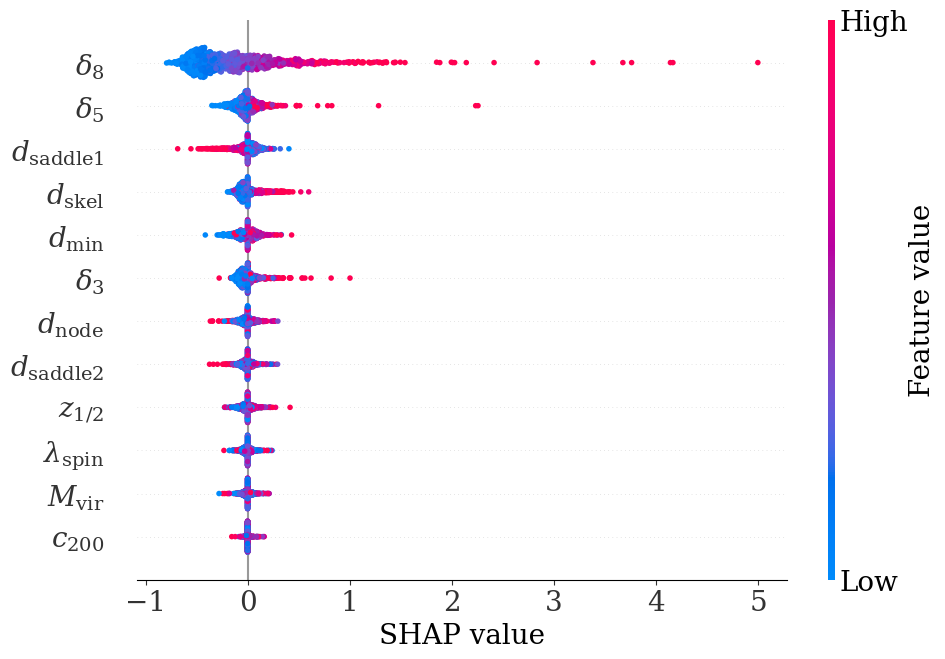

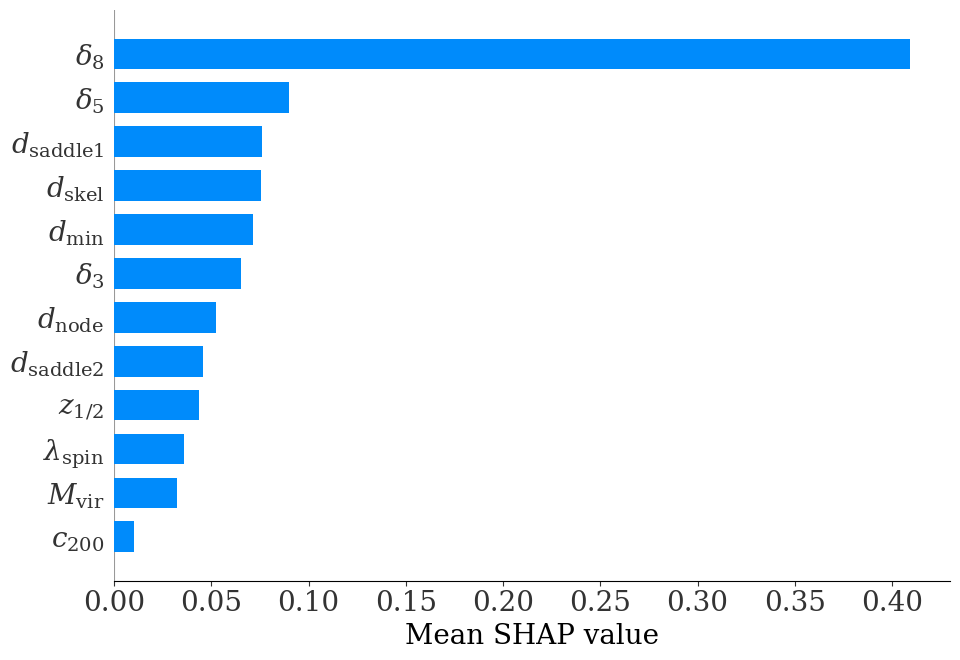

In [16]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "DejaVu Serif"
plt.rcParams["mathtext.it"] = "DejaVu Serif:italic"
plt.rcParams["mathtext.bf"] = "DejaVu Serif:bold"

feature_names = [
    r'$M_{\rm vir}$',
    r'$\delta_3$',
    r'$\delta_5$',
    r'$\delta_8$',
    r'$c_{200}$',
    r'$z_{1/2}$',
    r'$\lambda_{\rm spin}$',
    r'$d_{\rm min}$',
    r'$d_{\rm node}$',
    r'$d_{\rm saddle 1}$',
    r'$d_{\rm saddle 2}$',
    r'$d_{\rm skel}$'
]

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    max_display=12,
    show=False
)

fig = plt.gcf()
ax = plt.gca()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.xlabel("SHAP value", fontsize=20)

# Colorbar
cbar_ax = fig.axes[-1]
cbar_ax.tick_params(labelsize=20)
cbar_ax.set_ylabel("Feature value", fontsize=20)

plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png')
plt.show()

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar",
    max_display=12,
    show=False
)

ax = plt.gca()

ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

plt.xlabel("Mean SHAP value", fontsize=20)

plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig('shap_bar_plot.png')
plt.show()

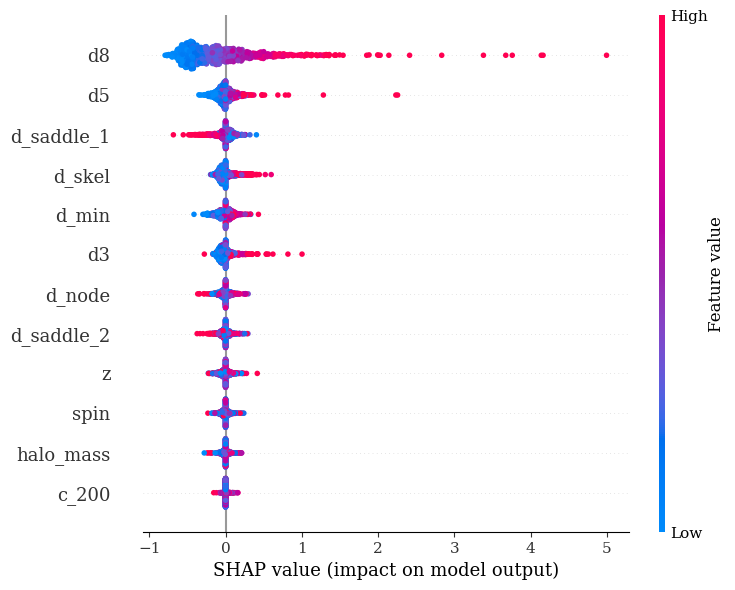

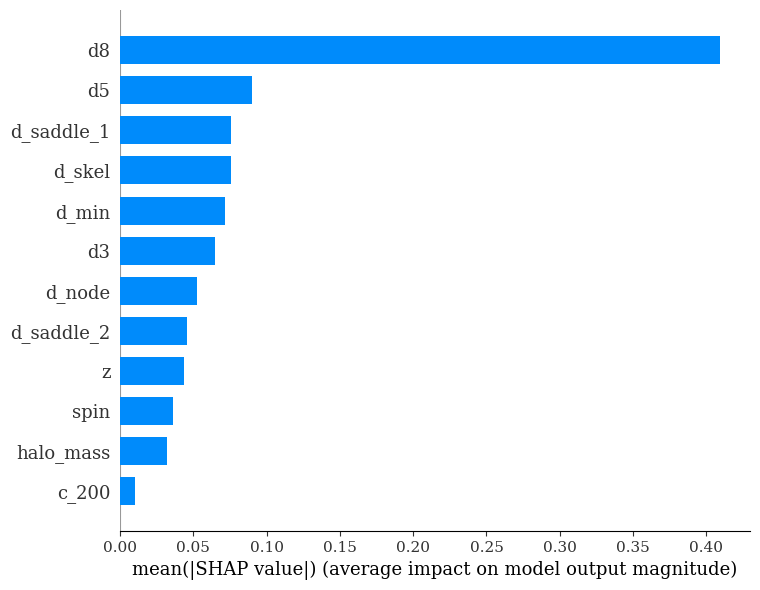

In [17]:
# Global feature importance — beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, show=True)

# Global feature importance — bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, plot_type='bar', show=True)

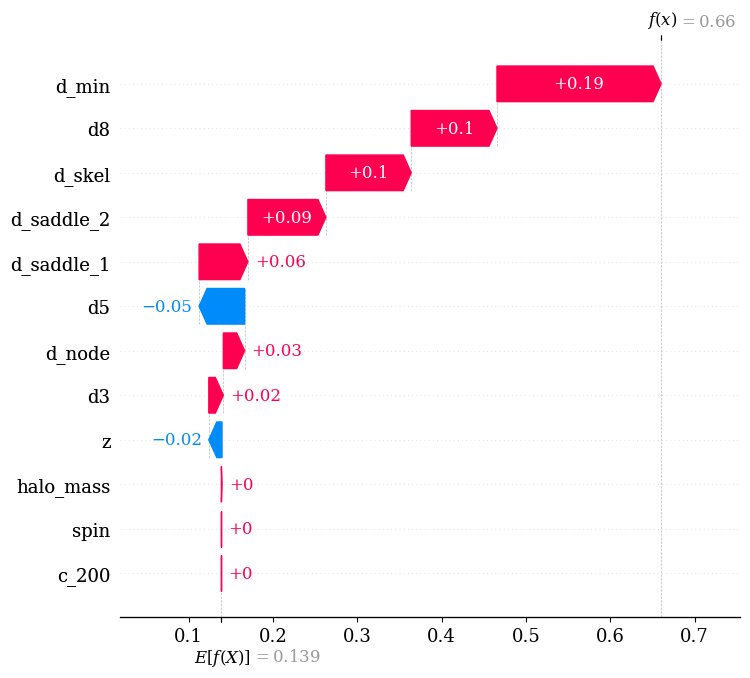

In [18]:
# Local explanation — waterfall for a single prediction
sample_id = 500
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_id],
    feature_names=features,
    max_display=12
)

In [25]:
# Wrapper Keras para Quantus:
# Quantus infiere channel_first=True de (N,1,12) y pasa los datos sin convertir.
# Input(1,12) + Permute(2,1) convierte internamente a (N,12,1) para el ResNet.
n_features = len(features)
inp_q = keras.Input(shape=(1, n_features))
x_q   = keras.layers.Permute((2, 1))(inp_q)
x_q   = model(x_q)
x_q   = keras.layers.Reshape((1,))(x_q)
out_q = keras.layers.Dense(1, activation='linear', use_bias=False)(x_q)
model_q = keras.Model(inputs=inp_q, outputs=out_q)
model_q.layers[-1].set_weights([np.ones((1, 1))])

# Subconjunto de 150 instancias para evaluación
n_eval    = 200
eval_idx  = np.random.default_rng(0).choice(400, size=n_eval, replace=False)
x_eval    = X_explain[eval_idx]
a_eval    = shap_values[eval_idx]

x_eval_q  = x_eval[:, np.newaxis, :]   # (150, 1, 12)
a_eval_q  = a_eval[:, np.newaxis, :]   # (150, 1, 12)
y_quantus = np.zeros(n_eval, dtype=int)

_s = model_q(x_eval_q[:2].astype('float32'), training=False)
print(f'model_q smoke (2,1,12) → {tuple(_s.shape)}  OK')

model_q smoke (2,1,12) → (2, 1)  OK


In [20]:
!pip install quantus

In [21]:
import shap, quantus, matplotlib.pyplot as plt, warnings

In [26]:
metric_fe = quantus.FaithfulnessEstimate(
    features_in_step=1,
    perturb_baseline='mean',
    return_aggregate=False,
)

scores_fe = np.array(metric_fe(
    model=model_q, x_batch=x_eval_q, y_batch=y_quantus, a_batch=a_eval_q
), dtype=float)

print(f'Faithfulness Estimate (↑ mejor)')
print(f'  media : {np.nanmean(scores_fe):.4f}')
print(f'  std   : {np.nanstd(scores_fe):.4f}')

Faithfulness Estimate (↑ mejor)
  media : 0.4601
  std   : 0.3138


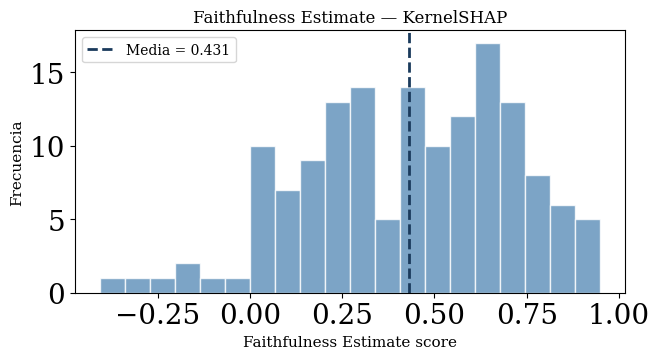

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
s = scores_fe[np.isfinite(scores_fe)]
ax.hist(s, bins=20, color='#5B8DB8', alpha=0.8, edgecolor='white')
ax.axvline(np.nanmean(s), color='#1a3a5c', linestyle='--', linewidth=2,
           label=f'Media = {np.nanmean(s):.3f}')
ax.set_xlabel('Faithfulness Estimate score', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Faithfulness Estimate — KernelSHAP', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()